# SCRUM-12: Draft Problem Statement Slide

**Task:** Draft the problem statement for the Review 1 presentation.

**Assignee:** Burra Vijay Krishna | **Sprint:** SCRUM Sprint 0

---

## Problem Statement

### The Problem
In today's fast-moving consumer electronics market, certain products experience sudden **viral demand surges** — driven by social media buzz, influencer reviews, and organic consumer interest. By the time businesses recognize these surges through traditional sales data, it is **too late** for:
- Inventory restocking
- Marketing campaign alignment
- Supply chain preparation
- Competitive pricing decisions

### The Opportunity
Early consumer signals — such as **search interest growth**, **YouTube review activity**, **sentiment trends**, and **social engagement patterns** — appear **days or weeks before** a visible demand surge.

### Our Approach
We collect multi-source consumer signal data (Google Trends, YouTube Data API) for **60 smartphones** in the Indian market:
- 🔴 **RISING** — newly launched or upcoming (24 products)
- 🟢 **STABLE** — current, steady-interest (24 products)
- 🔵 **DECLINING** — superseded or older (12 products)

### Business Value
| Stakeholder | Benefit |
|------------|--------|
| Retailers | Early inventory planning |
| Marketers | Optimal campaign timing |
| Manufacturers | Demand-driven production |
| Analysts | Data-driven trend forecasting |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DATA_DIR = os.path.join('..', 'data')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
YT_DIR = os.path.join(DATA_DIR, 'youtube')
print('Setup complete.')

Setup complete.


## Signal Sources — What We Collect

In [2]:
products = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
colors = {'RISING': '#e74c3c', 'STABLE': '#2ecc71', 'DECLINING': '#3498db'}

# Show the scope of our data collection
print('=== Project Scope ===')
print(f'Total products tracked: {len(products)}')
print(f'Brands covered: {products["brand"].nunique()}')
print(f'Market: India (Smartphones)')
print()
for ptype in ['RISING', 'STABLE', 'DECLINING']:
    count = len(products[products['product_type'] == ptype])
    print(f'  {ptype}: {count} products')

print()
print('=== Data Sources ===')
print('1. YouTube Data API v3 — video metrics, comments, upload activity')
print('2. Google Trends — relative search interest over time')
print()
print('=== Pilot Status ===')
collection_log = pd.read_csv(os.path.join(DATA_DIR, 'collection_log.csv'))
pilot = collection_log[collection_log['status'] == 'success']
print(f'Pilot products collected: {pilot["product_id"].nunique()}')
print(f'Total records: {pilot["records_collected"].sum()}')
print(f'All runs successful: {(collection_log["status"].isin(["success", "smoke_test_ok"])).all()}')

=== Project Scope ===
Total products tracked: 60
Brands covered: 13
Market: India (Smartphones)

  RISING: 24 products
  STABLE: 24 products
  DECLINING: 12 products

=== Data Sources ===
1. YouTube Data API v3 — video metrics, comments, upload activity
2. Google Trends — relative search interest over time

=== Pilot Status ===
Pilot products collected: 10
Total records: 6636
All runs successful: True


## Pilot YouTube Data — Early Signals Demonstration

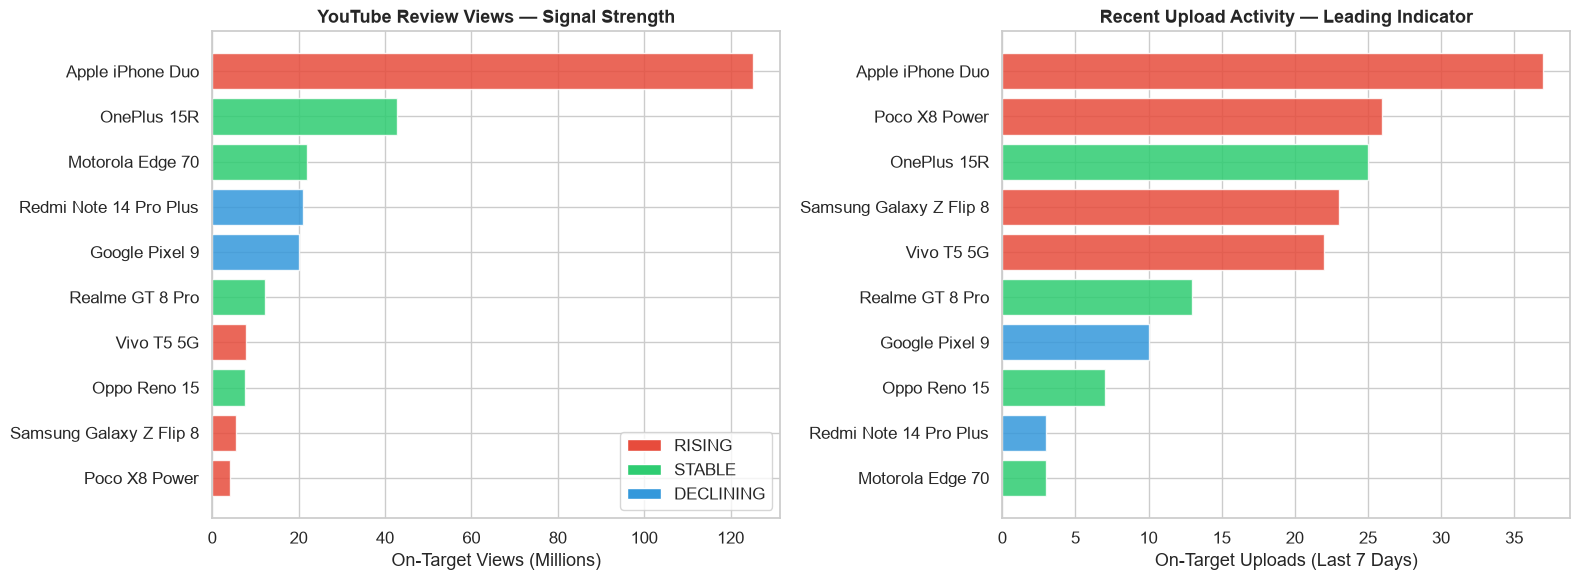

RISING products show higher recent upload activity — this is an early signal of demand.


In [3]:
# Show how different product types have different signal levels
yt_daily = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_product_daily_clean.csv'))
yt = yt_daily.merge(products[['product_id', 'product_name', 'brand', 'product_type']],
                    on='product_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Views by product type
s = yt.sort_values('views_on_target_total', ascending=True)
axes[0].barh(s['product_name'], s['views_on_target_total'] / 1e6,
             color=[colors.get(t, '#95a5a6') for t in s['product_type']], alpha=0.85)
axes[0].set_xlabel('On-Target Views (Millions)')
axes[0].set_title('YouTube Review Views — Signal Strength', fontsize=13, fontweight='bold')

# Recent uploads — leading indicator
yt_recent = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_recent_window_clean.csv'))
yt_r = yt_recent.merge(products[['product_id', 'product_name', 'product_type']],
                       on='product_id', how='left')
s2 = yt_r.sort_values('videos_7d_on_target', ascending=True)
axes[1].barh(s2['product_name'], s2['videos_7d_on_target'],
             color=[colors.get(t, '#95a5a6') for t in s2['product_type']], alpha=0.85)
axes[1].set_xlabel('On-Target Uploads (Last 7 Days)')
axes[1].set_title('Recent Upload Activity — Leading Indicator', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=c, label=l) for l, c in colors.items()], loc='lower right')
plt.tight_layout()
plt.show()

print('RISING products show higher recent upload activity — this is an early signal of demand.')

In [4]:
print('\n=== SCRUM-12 COMPLETE ===')
print('Problem statement drafted with supporting data visualizations.')


=== SCRUM-12 COMPLETE ===
Problem statement drafted with supporting data visualizations.
